Dataset URL: https://www.kaggle.com/datasets/mloey1/ahdd1
License(s): DbCL-1.0
ahdd1.zip: Skipping, found more recently modified local copy (use --force to force download)
replace ahdd1_data/Arabic Handwritten Digits Dataset CSV/csvTestImages 10k x 784.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: Images shape: (60000, 784)
Labels shape: (60000,)
Unique labels: [0 1 2 3 4 5 6 7 8 9]
(60000, 28, 28)
(10000, 28, 28)


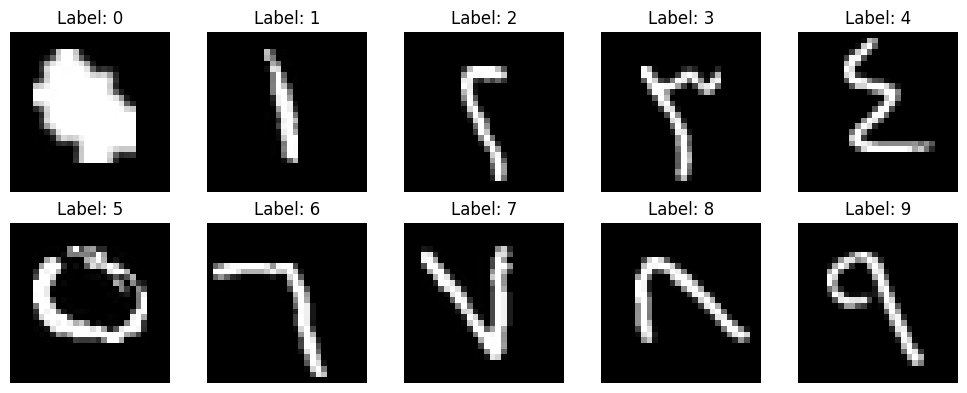

x_train shape: (60000, 32, 32, 1)
x_test shape: (10000, 32, 32, 1)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 1, 1, 120)      │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9017 - loss: 0.3464Epoch 1 time: 45.37s
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 23ms/step - accuracy: 0.9603 - loss: 0.1399 - val_accuracy: 0.9837 - val_loss: 0.0571
Epoch 2/5
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9875 - loss: 0.0433Epoch 2 time: 44.75s
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 24ms/step - accuracy: 0.9886 - loss: 0.0389 - val_accuracy: 0.9830 - val_loss: 0.0577
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9908 - loss: 0.0306Epoch 3 time: 43.29s
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.9913 - loss: 0.0287 - val_accuracy: 0.9866 - val_loss: 0.0451
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9928 - loss: 0.0243Epoch 4 time: 45.52s
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 24ms/step - accuracy: 0.9930 - loss: 0.0229 - val_accuracy: 0.9854 - val_loss: 0.0573
Epoch 5/5
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9937 - loss: 0.0

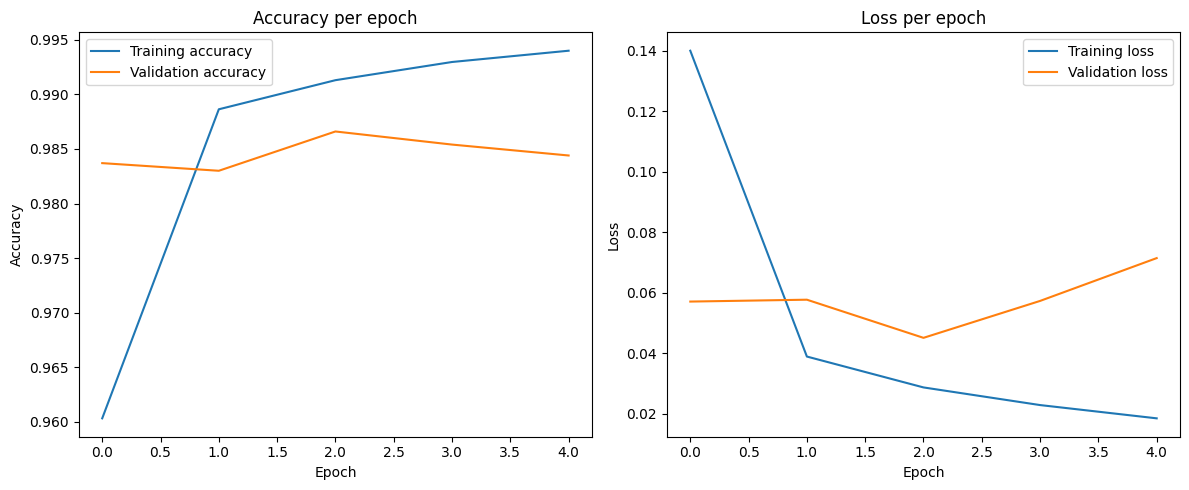

In [ ]:
##
#LeNet-5 implementation for MADBase

import tensorflow as tf
import matplotlib.pyplot as plt
import time

import pandas as pd
import numpy as np

import os
#os.environ['KAGGLE_API_TOKEN'] = 'KGAT_80bb18391678b94acddddbe0a042952a'

!pip install -q kaggle
!kaggle datasets download -d mloey1/ahdd1
!unzip -q ahdd1.zip -d ahdd1_data


train_images = pd.read_csv("ahdd1_data/csvTrainImages 60k x 784.csv", header=None).values
train_labels = pd.read_csv("ahdd1_data/csvTrainLabel 60k x 1.csv", header=None).values.flatten()

print(f"Images shape: {train_images.shape}")
print(f"Labels shape: {train_labels.shape}")
print(f"Unique labels: {np.unique(train_labels)}")

#fixed seed, required for reproducibility
#every time i run the notebook from scratch, i'll get the same initial weights and the same batch shuffle order
#model.fit() shuffles the training data before splitting it into batches each epoch by default. The order examples arrive in affects the gradient updates.
################################################################################################################

# load test set too, same way as train
test_images = pd.read_csv("ahdd1_data/csvTestImages 10k x 784.csv", header=None).values
test_labels = pd.read_csv("ahdd1_data/csvTestLabel 10k x 1.csv", header=None).values.flatten()

# reshape all images to (N, 28, 28), then transpose each one
train_images_2d = train_images.reshape(-1, 28, 28).transpose(0, 2, 1)
test_images_2d = test_images.reshape(-1, 28, 28).transpose(0, 2, 1)

print(train_images_2d.shape)  # (60000, 28, 28)
print(test_images_2d.shape)   # (10000, 28, 28)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(train_images_2d[i], cmap='gray')
    ax.set_title(f"Label: {train_labels[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

##########################################################################
tf.random.set_seed(23)



# add channel axis: (N,28,28) -> (N,28,28,1)
x_train = train_images_2d[..., tf.newaxis]
x_test = test_images_2d[..., tf.newaxis]

y_train = train_labels
y_test = test_labels

# zero-pad 28x28 -> 32x32, same as Task 1
x_train = tf.pad(x_train, [[0,0],[2,2],[2,2],[0,0]])
x_test = tf.pad(x_test, [[0,0],[2,2],[2,2],[0,0]])

# scale to [0,1] only - simple normalization, no mean/std standardization
x_train = tf.cast(x_train, tf.float32) / 255.0
x_test = tf.cast(x_test, tf.float32) / 255.0

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")

model = tf.keras.Sequential([
    ##first block contains 1 conv with 6 filters
    tf.keras.layers.Conv2D(6, (5,5),
        activation='relu', #it should be tanh as the paper
       # padding='same' ,## Keras automatically calculates and applies however much padding is needed so the output spatial size exactly matches the input spatial size (for stride 1)
        input_shape=(32,32,1)),
    ##28*28*6

    tf.keras.layers.AveragePooling2D((2,2)), #reducing feature map to quarter it's value
    ## 14*14*6


    ##second block contains 1 conv with 16 filters
    tf.keras.layers.Conv2D(16, (5,5),
        activation='relu',
    ##    padding='same') ,
    ),
    ##10*10*16

    tf.keras.layers.AveragePooling2D((2,2)),
    ##5*5*16

    ##third block contains 1 convs with 120 filters
    tf.keras.layers.Conv2D(120, (5,5),
        activation='relu') ,
    ##1*1*120


    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(84, activation='relu'),##this layer is after flatten
                                                  ##so it's input is 1*1*120 = 120


    tf.keras.layers.Dense(10, activation='softmax') ##replacement to the RBF (Euclidean Radial Basis Function)
])

model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

#
#getting training time per epoch
class EpochTimer(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []
    def on_epoch_begin(self, epoch, logs=None):
        self._start = time.time()
    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self._start
        self.epoch_times.append(elapsed)
        print(f"Epoch {epoch+1} time: {elapsed:.2f}s")

epoch_timer = EpochTimer()

# added: validation_data so Keras evaluates on the test set at the end of every epoch,
# and capturing the return value of fit() into `history` so we have per-epoch numbers to plot
history = model.fit(x_train, y_train,
          epochs=5, batch_size=32,
          validation_data=(x_test, y_test),
          callbacks=[epoch_timer])

model.evaluate(x_test, y_test)

avg_epoch_time = sum(epoch_timer.epoch_times) / len(epoch_timer.epoch_times)
print(f"Average training time per epoch: {avg_epoch_time:.2f}s")

# added: plot training vs validation accuracy and loss curves across epochs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(history.history['accuracy'], label='Training accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation accuracy')
ax1.set_title('Accuracy per epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Training loss')
ax2.plot(history.history['val_loss'], label='Validation loss')
ax2.set_title('Loss per epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()
model.save('lenet5_MADBase.keras')

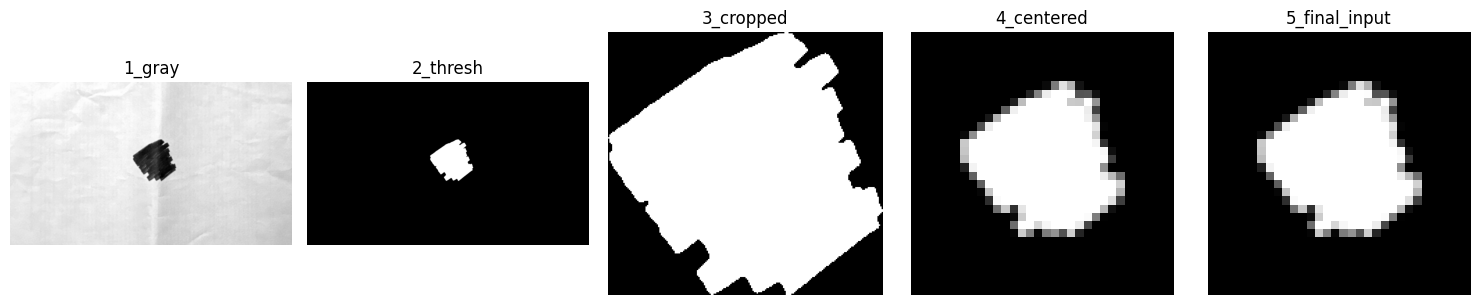

Saved pipeline figure to task2arabic_pipeline_figure3.png
Predicted digit: 0  (confidence: 99.99%)


In [ ]:
"""
preprocess.py - ELCT918 Lab 3, Task 2
Preprocessing pipeline: turns a photo/crop of a handwritten digit into a
32x32 tensor matching the exact distribution LeNet-5 was trained on in Task 1.
wanna run it on my local machine
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# must match EXACTLY what was used to train lenet5_MADBase.keras in Task 1
#MNIST_MEAN = 0.1307
#MNIST_STD = 0.3081


def preprocess(roi):
    """
    roi: a BGR color image (as OpenCV reads it) containing a handwritten
         digit on paper - either a full photo or a cropped camera region.

    Returns:
        tensor: (1, 32, 32, 1) float32 array ready for model.predict(), or
                None if no digit was found in the image.
        steps:  dict of intermediate images, for the Task 2 deliverable figure.
    """
    steps = {}

    # 1. Grayscale + blur (reduce camera sensor noise)
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)
    steps['1_gray'] = gray

    # 2. Threshold + invert -> white digit on black background, like MNIST
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    # if pen strokes are thin and get lost, thicken them:
    # thresh = cv2.dilate(thresh, np.ones((3, 3), np.uint8), iterations=1)
    steps['2_thresh'] = thresh

    # 3. Crop to the digit's bounding box
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        steps['3_cropped'] = thresh  # nothing found, show the blank threshold
        return None, steps
    largest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest)
    digit = thresh[y:y + h, x:x + w]
    steps['3_cropped'] = digit

    # 4. Resize (preserve aspect ratio, larger side -> 20px),
    #    center in 28x28, then pad to 32x32 (matches Task 1's padding)
    h, w = digit.shape
    if h >= w:
        new_h = 20
        new_w = max(1, round(w * 20 / h))
    else:
        new_w = 20
        new_h = max(1, round(h * 20 / w))
    resized = cv2.resize(digit, (new_w, new_h), interpolation=cv2.INTER_AREA)

    canvas28 = np.zeros((28, 28), dtype=np.uint8)
    y_off = (28 - new_h) // 2
    x_off = (28 - new_w) // 2
    canvas28[y_off:y_off + new_h, x_off:x_off + new_w] = resized

    canvas32 = cv2.copyMakeBorder(canvas28, 2, 2, 2, 2, cv2.BORDER_CONSTANT, value=0)
    steps['4_centered'] = canvas32

    # 5. Convert to tensor
    tensor = canvas32.astype('float32') / 255.0
    #tensor = (tensor - MNIST_MEAN) / MNIST_STD
    tensor = tensor.reshape(1, 32, 32, 1)
    steps['5_final_input'] = canvas32  # keep uint8 version just for display

    return tensor, steps


def show_pipeline_figure(steps, save_path='task2arabic_pipeline_figure3.png'):
    """Deliverable: a figure showing the output of each step for one digit."""
    fig, axes = plt.subplots(1, len(steps), figsize=(3 * len(steps), 3))
    if len(steps) == 1:
        axes = [axes]
    for ax, (name, img) in zip(axes, steps.items()):
        ax.imshow(img, cmap='gray')
        ax.set_title(name)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved pipeline figure to {save_path}")


if __name__ == "__main__":
    # ---- quick standalone test / Task 2 deliverable generation ----
    # replace with a photo of a handwritten digit on paper (phone photo or
    # a single webcam frame saved to disk)
    IMAGE_PATH = "my_arabic_digit_photo3.jpg"

    roi = cv2.imread(IMAGE_PATH)
    if roi is None:
        raise FileNotFoundError(f"Could not read {IMAGE_PATH} - check the path.")

    tensor, steps = preprocess(roi)
    show_pipeline_figure(steps)

    if tensor is not None:
        # sanity-check prediction using the Task 1 model
        model = tf.keras.models.load_model("lenet5_MADBase.keras")
        probs = model.predict(tensor, verbose=0)[0]
        pred = int(np.argmax(probs))
        confidence = float(probs[pred])
        print(f"Predicted digit: {pred}  (confidence: {confidence:.2%})")
    else:
        print("No digit detected in the image - check lighting/contrast.")

In [ ]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_80bb18391678b94acddddbe0a042952a'

!pip install -q kaggle
!kaggle datasets download -d mloey1/ahdd1
!unzip -q ahdd1.zip -d ahdd1_data


Dataset URL: https://www.kaggle.com/datasets/mloey1/ahdd1
License(s): DbCL-1.0
100% 50.6M/50.6M [00:00<00:00, 99.0MB/s]



In [ ]:
!ls ahdd1_data

'Arabic Handwritten Digits Dataset CSV'  'csvTrainImages 60k x 784.csv'
'csvTestImages 10k x 784.csv'		 'csvTrainLabel 60k x 1.csv'
'csvTestLabel 10k x 1.csv'		 'Train + Test Matlab.mat'
'csvTrainImages 60k x 784'


In [ ]:
import pandas as pd
import numpy as np

train_images = pd.read_csv("ahdd1_data/csvTrainImages 60k x 784.csv", header=None).values
train_labels = pd.read_csv("ahdd1_data/csvTrainLabel 60k x 1.csv", header=None).values.flatten()

print(f"Images shape: {train_images.shape}")
print(f"Labels shape: {train_labels.shape}")
print(f"Unique labels: {np.unique(train_labels)}")

Images shape: (60000, 784)
Labels shape: (60000,)
Unique labels: [0 1 2 3 4 5 6 7 8 9]


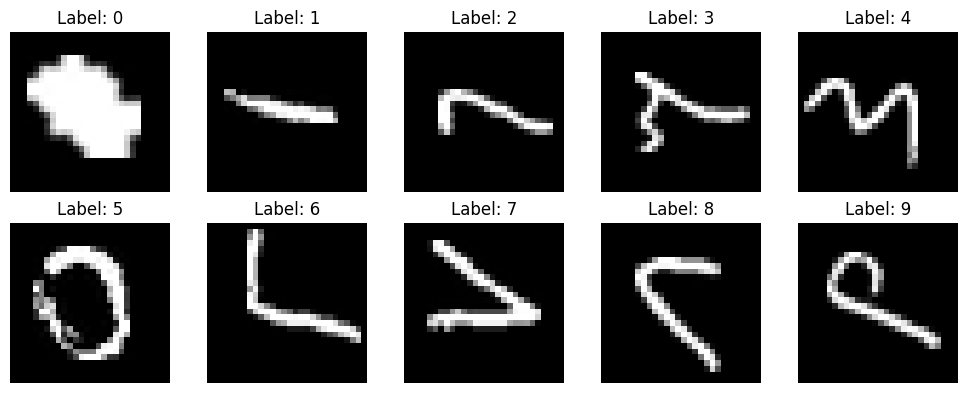

In [ ]:
import matplotlib.pyplot as plt

sample_imgs = train_images[:10].reshape(-1, 28, 28)
#reshape(-1, 28, 28) is equivalent to writing reshape(10, 28, 28) explicitly,
#just without you having to calculate or hardcode that 10 yourself (handy if you ever change [:10] to [:20] or similar — the -1 adjusts automatically

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_imgs[i], cmap='gray')
    ax.set_title(f"Label: {train_labels[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

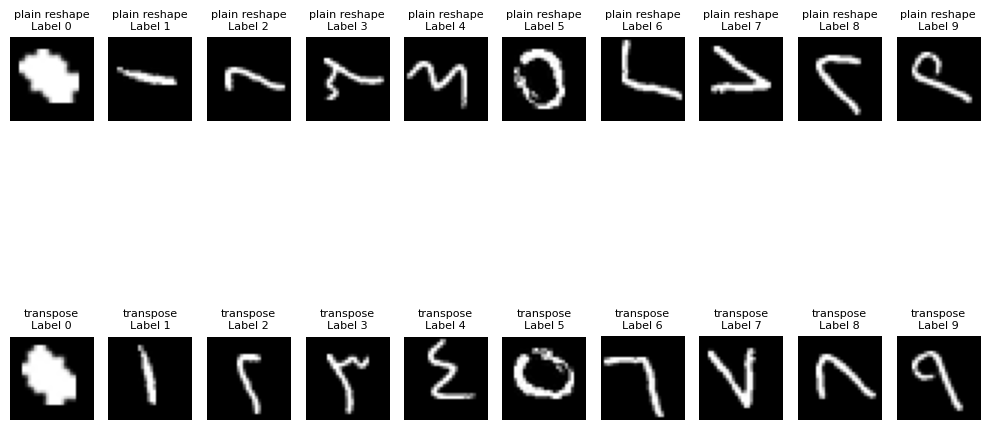

(60000, 28, 28)
(10000, 28, 28)


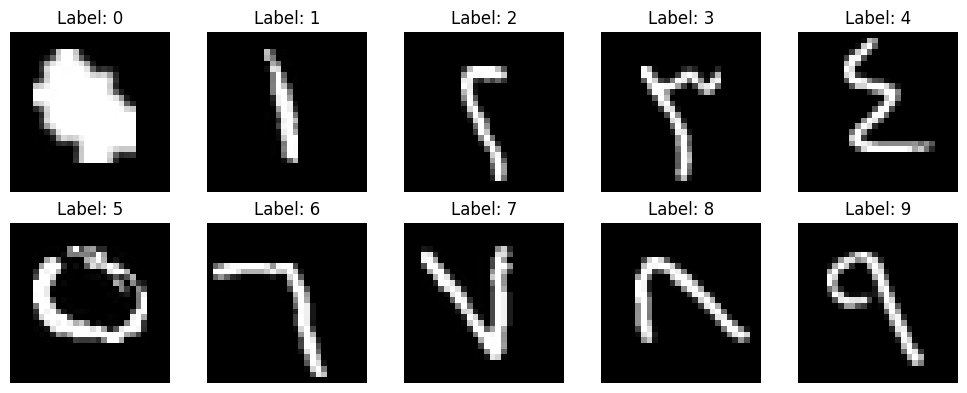

In [ ]:
fig, axes = plt.subplots(2, 10, figsize=(10, 8))

img = train_images[0]  # label 0, should look like a dot/small circle (٠)

candidates = {
    'plain reshape':        img.reshape(28, 28),
    'transpose':             img.reshape(28, 28).T,
    #"order='F' reshape":     img.reshape(28, 28, order='F'),
    #'transpose + flip LR':   np.fliplr(img.reshape(28, 28).T),
}

for row, (name, transformed) in enumerate(candidates.items()):
    for col in range(10):
        im = train_images[col].reshape(28, 28) if name == 'plain reshape' else None
        # apply the same transform to each of the first 5 images
        raw = train_images[col]
        if name == 'plain reshape':
            im = raw.reshape(28, 28)
        elif name == 'transpose':
            im = raw.reshape(28, 28).T
        #elif name == "order='F' reshape":
         #   im = raw.reshape(28, 28, order='F')
        #elif name == 'transpose + flip LR':
         #   im = np.fliplr(raw.reshape(28, 28).T)
        axes[row, col].imshow(im, cmap='gray')
        axes[row, col].set_title(f"{name}\nLabel {train_labels[col]}", fontsize=8)
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# load test set too, same way as train
test_images = pd.read_csv("ahdd1_data/csvTestImages 10k x 784.csv", header=None).values
test_labels = pd.read_csv("ahdd1_data/csvTestLabel 10k x 1.csv", header=None).values.flatten()

# reshape all images to (N, 28, 28), then transpose each one
train_images_2d = train_images.reshape(-1, 28, 28).transpose(0, 2, 1)
test_images_2d = test_images.reshape(-1, 28, 28).transpose(0, 2, 1)

print(train_images_2d.shape)  # (60000, 28, 28)
print(test_images_2d.shape)   # (10000, 28, 28)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(train_images_2d[i], cmap='gray')
    ax.set_title(f"Label: {train_labels[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

Dataset URL: https://www.kaggle.com/datasets/mloey1/ahdd1
License(s): DbCL-1.0
100% 50.6M/50.6M [00:00<00:00, 130MB/s]



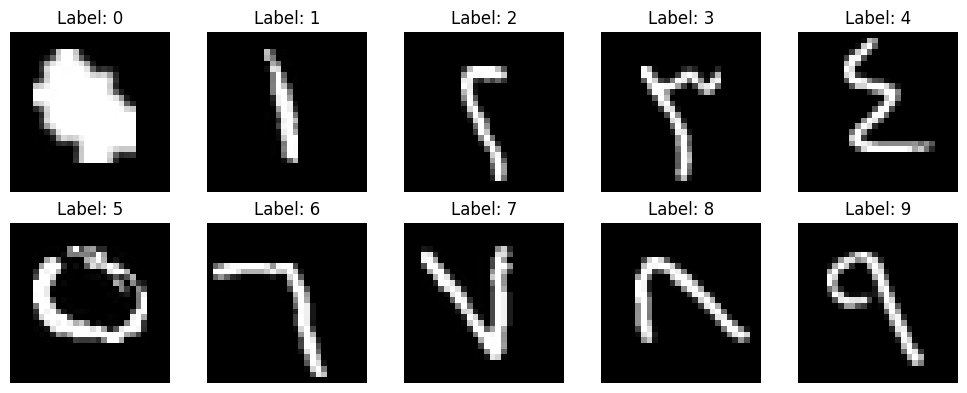

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Combined train images: (120000, 32, 32, 1)
Combined train labels: (120000,)
Combined test images: (20000, 32, 32, 1)
Combined test labels: (20000,)
Unique combined labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 1, 1, 120)      │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         1,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,556 (244.36 KB)

 Trainable params: 62,556 (244.36 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
3747/3750 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8599 - loss: 0.4814Epoch 1 time: 54.59s
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 55s 14ms/step - accuracy: 0.9330 - loss: 0.2257 - val_accuracy: 0.9671 - val_loss: 0.1023
Epoch 2/5
3748/3750 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9733 - loss: 0.0868Epoch 2 time: 48.79s
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 49s 13ms/step - accuracy: 0.9757 - loss: 0.0789 - val_accuracy: 0.9748 - val_loss: 0.0749
Epoch 3/5
3746/3750 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9809 - loss: 0.0607Epoch 3 time: 45.30s
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 45s 12ms/step - accuracy: 0.9820 - loss: 0.0570 - val_accuracy: 0.9809 - val_loss: 0.0603
Epoch 4/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9851 - loss: 0.0467Epoch 4 time: 84.19s
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 84s 13ms/step - accuracy: 0.9857 - loss: 0.0450 - val_accuracy: 0.9818 - val_loss: 0.0559
Epoch 5/5
3749/3750 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9876 - loss: 0.0

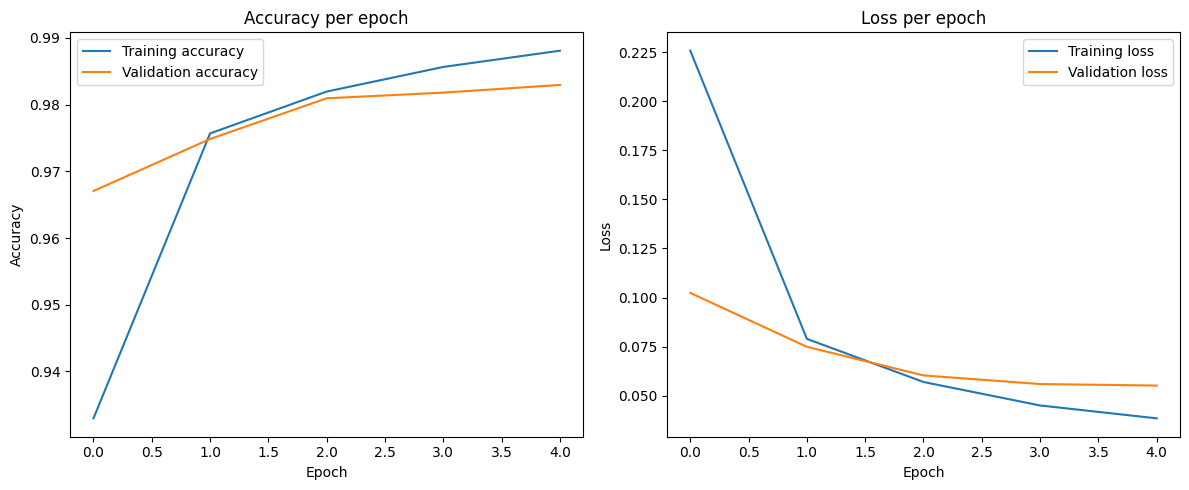

True Western -> Predicted Arabic (should be near-zero everywhere):
[[0 0 0 0 0 1 0 0 0 0]
 [0 6 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 4 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1]]

True Arabic -> Predicted Western (should be near-zero everywhere):
[[ 0  1  0  0  0  0  0  0  2  2]
 [ 0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  1  2  0  0  1  0]
 [ 0  0  0  0  0  1  0  0  1  0]
 [ 0  0  5  0  0  0  0  0  0  0]
 [28  0  0  0  0  2  1  0  1  3]
 [ 0  0  0  1  0  0  0  8  0  0]
 [ 0  0  1  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  1]
 [ 0  0  0  0  0  0  0  0  1 16]]

Top cross-system confusions (count, true_label, predicted_label):
  6 test samples: true=1  predicted=ar1
  4 test samples: true=7  predicted=ar6
  1 test samples: true=9  predicted=ar9
  1 test samples: true=2  predicted=ar4
  1 test samples: true=0  predicted=ar5
  28 test samples: true=ar5  predict

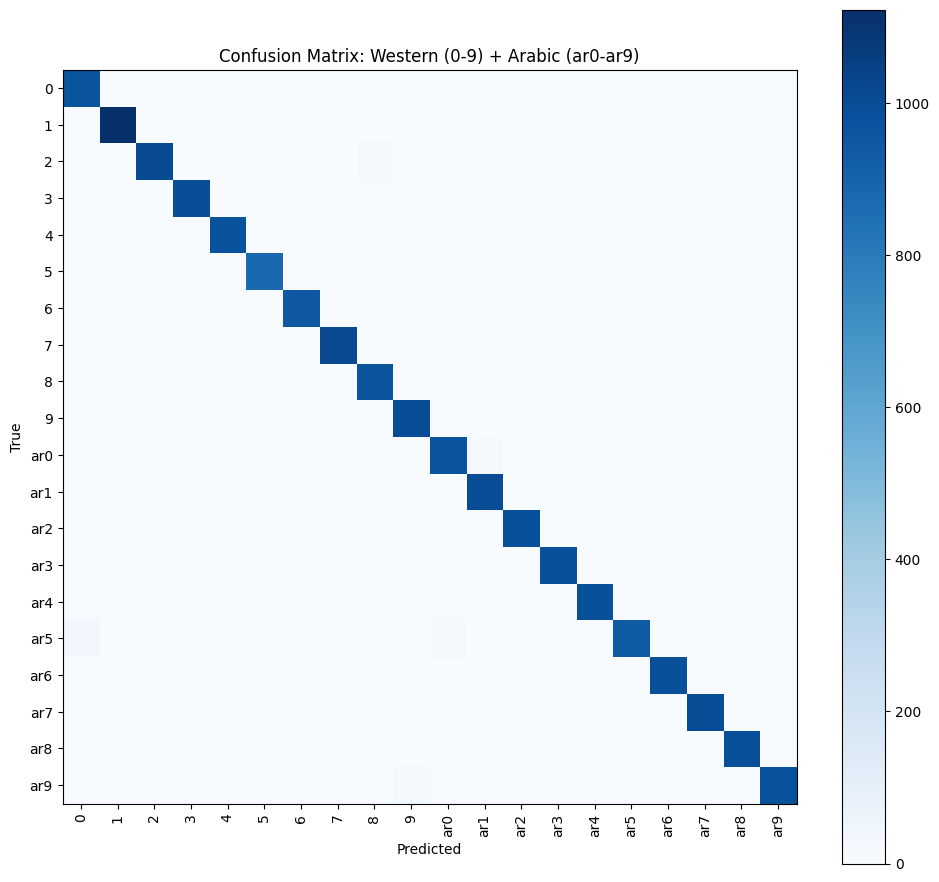

In [1]:
##combining both data sets
##
#LeNet-5 implementation

import tensorflow as tf
import matplotlib.pyplot as plt
import time

import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
import numpy as np

import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_80bb18391678b94acddddbe0a042952a'

!pip install -q kaggle
!kaggle datasets download -d mloey1/ahdd1
!unzip -q ahdd1.zip -d ahdd1_data


train_images_arabic = pd.read_csv("ahdd1_data/csvTrainImages 60k x 784.csv", header=None).values
train_labels_arabic = pd.read_csv("ahdd1_data/csvTrainLabel 60k x 1.csv", header=None).values.flatten()

#print(f"Images shape: {train_images_arabic.shape}")
#print(f"Labels shape: {train_labels_arabic.shape}")
#print(f"Unique labels: {np.unique(train_labels_arabic)}")


################################################################################################################

test_images_arabic = pd.read_csv("ahdd1_data/csvTestImages 10k x 784.csv", header=None).values
test_labels_arabic = pd.read_csv("ahdd1_data/csvTestLabel 10k x 1.csv", header=None).values.flatten()

# reshape all images to (N, 28, 28), then transpose each one
train_images_2d_arabic = train_images_arabic.reshape(-1, 28, 28).transpose(0, 2, 1)
test_images_2d_arabic = test_images_arabic.reshape(-1, 28, 28).transpose(0, 2, 1)

#print(train_images_2d_arabic.shape)  # (60000, 28, 28)
#print(test_images_2d_arabic.shape)   # (10000, 28, 28)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(train_images_2d_arabic[i], cmap='gray')
    ax.set_title(f"Label: {train_labels_arabic[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

##########################################################################
#fixed seed, required for reproducibility
#every time i run the notebook from scratch, i'll get the same initial weights and the same batch shuffle order
#model.fit() shuffles the training data before splitting it into batches each epoch by default. The order examples arrive in affects the gradient updates.
tf.random.set_seed(23)



# add channel axis: (N,28,28) -> (N,28,28,1)
x_train_arabic = train_images_2d_arabic[..., tf.newaxis]
x_test_arabic = test_images_2d_arabic[..., tf.newaxis]

#y_train_arabic = train_labels_arabic
#y_test_arabic = test_labels_arabic

# zero-pad 28x28 -> 32x32, same as Task 1
x_train_arabic = tf.pad(x_train_arabic, [[0,0],[2,2],[2,2],[0,0]])
x_test_arabic = tf.pad(x_test_arabic, [[0,0],[2,2],[2,2],[0,0]])

# scale to [0,1] only - simple normalization, no mean/std standardization
x_train_arabic = tf.cast(x_train_arabic, tf.float32) / 255.0
x_test_arabic = tf.cast(x_test_arabic, tf.float32) / 255.0

#print(f"x_train shape: {x_train_arabic.shape}")
#print(f"x_test shape: {x_test_arabic.shape}")


# shift MADBase labels: 0-9 -> 10-19
madbase_y_train_shifted = train_labels_arabic + 10
madbase_y_test_shifted = test_labels_arabic + 10


################the western digits###############################
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

#MNIST comes as (N, 28, 28) with no channel axis coming from mnist.load_data()
#but LeNet-5 needs (N, H, W, C)
x_train = x_train[..., tf.newaxis] #inserts a new axis of size 1 at the end, turning (N, 28, 28) into (N, 28, 28, 1)
x_test = x_test[..., tf.newaxis]

#zero-pad 28x28 to 32x32
x_train = tf.pad(x_train, [[0,0],[2,2],[2,2],[0,0]])
x_test = tf.pad(x_test, [[0,0],[2,2],[2,2],[0,0]])
#################################################################
# combine images (stack along the first axis - more images, same shape)
combined_x_train = tf.concat([x_train, x_train_arabic], axis=0)
combined_x_test = tf.concat([x_test, x_test_arabic], axis=0)

# combine labels the same way, same order
combined_y_train = np.concatenate([y_train, madbase_y_train_shifted], axis=0)
combined_y_test = np.concatenate([y_test, madbase_y_test_shifted], axis=0)

print(f"Combined train images: {combined_x_train.shape}")
print(f"Combined train labels: {combined_y_train.shape}")
print(f"Combined test images: {combined_x_test.shape}")
print(f"Combined test labels: {combined_y_test.shape}")
print(f"Unique combined labels: {np.unique(combined_y_train)}")


#############################################################
model = tf.keras.Sequential([
    ##first block contains 1 conv with 6 filters
    tf.keras.layers.Conv2D(6, (5,5),
        activation='relu', #it should be tanh as the paper
       # padding='same' ,## Keras automatically calculates and applies however much padding is needed so the output spatial size exactly matches the input spatial size (for stride 1)
        input_shape=(32,32,1)),
    ##28*28*6

    tf.keras.layers.AveragePooling2D((2,2)), #reducing feature map to quarter it's value
    ## 14*14*6


    ##second block contains 1 conv with 16 filters
    tf.keras.layers.Conv2D(16, (5,5),
        activation='relu',
    ##    padding='same') ,
    ),
    ##10*10*16

    tf.keras.layers.AveragePooling2D((2,2)),
    ##5*5*16

    ##third block contains 1 convs with 120 filters
    tf.keras.layers.Conv2D(120, (5,5),
        activation='relu') ,
    ##1*1*120


    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(84, activation='relu'),##this layer is after flatten
                                                  ##so it's input is 1*1*120 = 120

#combining both datasets, i have 20 class
    tf.keras.layers.Dense(20, activation='softmax') ##replacement to the RBF (Euclidean Radial Basis Function)
])

model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

#
#getting training time per epoch
class EpochTimer(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []
    def on_epoch_begin(self, epoch, logs=None):
        self._start = time.time()
    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self._start
        self.epoch_times.append(elapsed)
        print(f"Epoch {epoch+1} time: {elapsed:.2f}s")

epoch_timer = EpochTimer()

# added: validation_data so Keras evaluates on the test set at the end of every epoch,
# and capturing the return value of fit() into `history` so we have per-epoch numbers to plot
history = model.fit(combined_x_train, combined_y_train,
          epochs=5, batch_size=32,
          validation_data=(combined_x_test, combined_y_test),
          callbacks=[epoch_timer])

model.evaluate(combined_x_test, combined_y_test)

avg_epoch_time = sum(epoch_timer.epoch_times) / len(epoch_timer.epoch_times)
print(f"Average training time per epoch: {avg_epoch_time:.2f}s")

# added: plot training vs validation accuracy and loss curves across epochs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(history.history['accuracy'], label='Training accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation accuracy')
ax1.set_title('Accuracy per epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Training loss')
ax2.plot(history.history['val_loss'], label='Validation loss')
ax2.set_title('Loss per epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()
model.save('lenet5_combined.keras')
####################################################################
#confusion matrix

model = tf.keras.models.load_model('lenet5_combined.keras')

probs = model.predict(combined_x_test, verbose=0)
y_pred = np.argmax(probs, axis=1)
y_true = np.array(combined_y_test)

cm = confusion_matrix(y_true, y_pred, labels=list(range(20)))

# Label convention: 0-9 = Western digits, 10-19 = Arabic digits (label - 10 = actual digit value)
labels = [str(i) for i in range(10)] + [f"ar{i}" for i in range(10)]

# Cross-system quadrants only:
# top-right: true Western (rows 0-9), predicted Arabic (cols 10-19)
western_to_arabic = cm[0:10, 10:20]
# bottom-left: true Arabic (rows 10-19), predicted Western (cols 0-9)
arabic_to_western = cm[10:20, 0:10]

print("True Western -> Predicted Arabic (should be near-zero everywhere):")
print(western_to_arabic)
print("\nTrue Arabic -> Predicted Western (should be near-zero everywhere):")
print(arabic_to_western)

# Find the biggest cross-system confusions automatically
def top_confusions(block, row_offset, col_offset, k=5):
    flat = [(block[i, j], i + row_offset, j + col_offset)
            for i in range(block.shape[0]) for j in range(block.shape[1])]
    flat.sort(reverse=True)
    return flat[:k]

print("\nTop cross-system confusions (count, true_label, predicted_label):")
for count, i, j in top_confusions(western_to_arabic, 0, 10) + top_confusions(arabic_to_western, 10, 0):
    if count > 0:
        true_name = labels[i]
        pred_name = labels[j]
        print(f"  {count} test samples: true={true_name}  predicted={pred_name}")

# Visualize the full 20x20 matrix
plt.figure(figsize=(10, 9))
plt.imshow(cm, cmap='Blues')
plt.xticks(range(20), labels, rotation=90)
plt.yticks(range(20), labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix: Western (0-9) + Arabic (ar0-ar9)')
plt.colorbar()
plt.tight_layout()
plt.savefig('combined_confusion_matrix.png', dpi=150)
plt.show()
